# 🎵 Playlist Sorter
Laadt een `combined.csv` bestand en sorteert songs in **Calm**, **Energy** en **Other** op basis van instelbare parameters.

---

## 1. Imports & Bestand laden

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

from pathlib import Path



In [2]:
os.getcwd()


'c:\\Users\\astri\\Desktop\\Data_Scientist\\Eindwerk\\spotify-project\\notebooks'

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  PADEN
# ══════════════════════════════════════════════════════════════════════════════
PARTICIPANT = "courgette"                                    # codename van de deelnemer
INPUT_DIR   = Path(f"../data/playlists/{PARTICIPANT}/losse_csv")        # map met Exportify CSV's
OUTPUT_DIR  = Path(f"../data/playlists/{PARTICIPANT}/playlists_generated")            # output map

# ══════════════════════════════════════════════════════════════════════════════
#  PREPARE – filters voor ongeschikte songs
# ══════════════════════════════════════════════════════════════════════════════
MAX_SPEECHINESS = 0.70   # > deze waarde = te veel gesproken woord
MAX_LIVENESS    = 0.80   # > deze waarde = live-opname met publiek


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  PREPARE: CSV's inladen & opschonen
# ══════════════════════════════════════════════════════════════════════════════


COLUMN_MAPPING = {
    'Track Name'       : 'name',
    'Artist Name(s)'   : 'artists',
    'Album Name'       : 'album',
    'Duration (ms)'    : 'duration_ms',
    'Tempo'            : 'tempo',
    'Energy'           : 'energy',
    'Valence'          : 'valence',
    'Acousticness'     : 'acousticness',
    'Danceability'     : 'danceability',
    'Loudness'         : 'loudness',
    'Speechiness'      : 'speechiness',
    'Instrumentalness' : 'instrumentalness',
    'Liveness'         : 'liveness',
    'Key'              : 'key',
    'Mode'             : 'mode',
    'Time Signature'   : 'time_signature',
    'Track URI'        : 'uri',
}

# Stap 1: CSV bestanden vinden
csv_files = sorted(INPUT_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Geen CSV bestanden gevonden in: {INPUT_DIR}")
print(f"Gevonden: {len(csv_files)} CSV bestand(en)")
for f in csv_files:
    print(f"  - {f.name}")

# Stap 2: Inladen & combineren
frames = []
for f in csv_files:
    try:
        frames.append(pd.read_csv(f))
    except Exception as e:
        print(f"  Kon {f.name} niet lezen: {e}")
df = pd.concat(frames, ignore_index=True)
print(f"\nTotaal ingeladen: {len(df)} rijen")

# Stap 3: Kolommen hernoemen
df = df.rename(columns={k: v for k, v in COLUMN_MAPPING.items() if k in df.columns})

# Stap 4: Duplicaten verwijderen op basis van Track URI
before = len(df)
if 'uri' in df.columns:
    df = df.drop_duplicates(subset=['uri'], keep='first')
    removed = before - len(df)
    if removed:
        print(f"Duplicaten verwijderd (URI): {removed}")

# Stap 4b: Duplicaten verwijderen op basis van naam + artiest (zelfde song, andere URI)
before = len(df)
df = df.drop_duplicates(subset=['name', 'artists'], keep='first')
removed = before - len(df)
if removed:
    print(f"Duplicaten verwijderd (naam + artiest): {removed}")

# Stap 5: Ongeschikte songs filteren
before = len(df)
if 'duration_ms' in df.columns:
    df = df[df['duration_ms'].between(60000, 300000)]
if 'speechiness' in df.columns:
    df = df[df['speechiness'] <= MAX_SPEECHINESS]
if 'liveness' in df.columns:
    df = df[df['liveness'] <= MAX_LIVENESS]
removed = before - len(df)
if removed:
    print(f"Ongeschikt gefilterd: {removed} (duration / speechiness / liveness)")

# Stap 6: combined.csv opslaan
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_DIR / 'combined.csv', index=False)

print(f"\nKlaar: {len(df)} unieke songs")
print(f"Opgeslagen: {OUTPUT_DIR / 'combined.csv'}")
df.head(3)

Gevonden: 1 CSV bestand(en)
  - Massalijst.csv

Totaal ingeladen: 6745 rijen
Duplicaten verwijderd (URI): 1
Duplicaten verwijderd (naam + artiest): 247
Ongeschikt gefilterd: 777 (duration / speechiness / liveness)

Klaar: 5720 unieke songs
Opgeslagen: ..\data\playlists\courgette\playlists_generated\combined.csv


,uri,name,album,artists,Release Date,duration_ms,Popularity,Explicit,Added By,Added At,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,spotify:track:4pvb0WLRcMtbPGmtejJJ6y,exile (feat. Bon Iver),folklore,Taylor Swift;Bon Iver,2020-07-24,285634,80,False,astrid.verschraege,2026-03-25T08:31:30Z,...,6.0,-8.426,1.0,0.0287,0.778,0.000056,0.110,0.152,75.602,4.0
1,spotify:track:69O18s28CWdA7ixXHBAKkh,The Light Upon Us,Far Out Dust,Talos,2019-02-08,229000,0,False,astrid.verschraege,2026-03-25T08:31:30Z,...,3.0,-3.484,0.0,0.0330,0.584,0.001980,0.387,0.283,95.133,3.0
2,spotify:track:3XwOaKFb6sH0K6BfNJ4VDq,Shine,Shine (Kygo Remix),Benjamin Francis Leftwich,2014-01-01,178040,0,False,astrid.verschraege,2026-03-25T08:31:30Z,...,4.0,-10.388,1.0,0.0300,0.653,0.000002,0.309,0.702,118.067,4.0


In [5]:
# ── Pad naar je combined.csv ──────────────────────────────────────────────────
CSV_PATH = "../data/playlists/courgette/playlists_generated/combined.csv"   # <-- pas dit aan naar jouw pad
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f"✅ Geladen: {len(df)} songs")
print(f"Kolommen: {list(df.columns)}")
df.head(3)


✅ Geladen: 5720 songs
Kolommen: ['uri', 'name', 'album', 'artists', 'Release Date', 'duration_ms', 'Popularity', 'Explicit', 'Added By', 'Added At', 'Genres', 'Record Label', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


,uri,name,album,artists,Release Date,duration_ms,Popularity,Explicit,Added By,Added At,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,spotify:track:4pvb0WLRcMtbPGmtejJJ6y,exile (feat. Bon Iver),folklore,Taylor Swift;Bon Iver,2020-07-24,285634,80,False,astrid.verschraege,2026-03-25T08:31:30Z,...,6.0,-8.426,1.0,0.0287,0.778,0.000056,0.110,0.152,75.602,4.0
1,spotify:track:69O18s28CWdA7ixXHBAKkh,The Light Upon Us,Far Out Dust,Talos,2019-02-08,229000,0,False,astrid.verschraege,2026-03-25T08:31:30Z,...,3.0,-3.484,0.0,0.0330,0.584,0.001980,0.387,0.283,95.133,3.0
2,spotify:track:3XwOaKFb6sH0K6BfNJ4VDq,Shine,Shine (Kygo Remix),Benjamin Francis Leftwich,2014-01-01,178040,0,False,astrid.verschraege,2026-03-25T08:31:30Z,...,4.0,-10.388,1.0,0.0300,0.653,0.000002,0.309,0.702,118.067,4.0


---
## 2. ⚙️ Parameters instellen
**Pas hier de grenswaarden aan.** Alles wat niet in Calm of Energy valt, gaat naar Other.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  CALM parameters
# ══════════════════════════════════════════════════════════════════════════════
CALM = dict(
    tempo_min        = 50,    # BPM
    tempo_max        = 90,    # BPM
    energy_max       = 0.50,  # 0.0 – 1.0
    acousticness_min = 0.0,  # 0.0 – 1.0  (zet op 0 om te negeren)
    valence_min      = 0.35,   # 0.0 – 1.0  (zet op 0 om te negeren)
    valence_max      = 1.0,   # 0.0 – 1.0  (zet op 1 om te negeren)
    loudness_min     = -20,   # dB
    loudness_max     = -5,    # dB
    danceability_min = 0.50,   # 0.0 – 1.0  (zet op 0 om te negeren)
    liveness_max     = 0.8,    # exclude live tracks
    
)

# ══════════════════════════════════════════════════════════════════════════════
#  ENERGY parameters
# ══════════════════════════════════════════════════════════════════════════════
ENERGY = dict(
    tempo_min        = 120,   # BPM
    tempo_max        = 200,   # BPM
    energy_min       = 0.60,  # 0.0 – 1.0
    danceability_min = 0.50,  # 0.0 – 1.0  (zet op 0 om te negeren)
    valence_min      = 0.45,  # 0.0 – 1.0  (zet op 0 om te negeren)
    loudness_min     = -12,   # dB
    liveness_max     = 0.8    # exclude live tracks

)

print("Parameters ingesteld ✅")

Parameters ingesteld ✅


---
## 3. Filteren & Sorteren

In [7]:
def has_col(df, col):
    return col in df.columns


def filter_calm(df, p):
    mask = df['tempo'].between(p['tempo_min'], p['tempo_max'])
    mask &= df['energy'] < p['energy_max']
    if has_col(df, 'acousticness'):
        mask &= df['acousticness'] >= p['acousticness_min']
    if has_col(df, 'valence'):
        mask &= df['valence'].between(p['valence_min'], p['valence_max'])
    if has_col(df, 'loudness'):
        mask &= df['loudness'].between(p['loudness_min'], p['loudness_max'])
    if has_col(df, 'danceability'):
        mask &= df['danceability'] >= p['danceability_min']
    result = df[mask].copy()
    # ISO volgorde: hoog -> laag activatie (stress -> rust)
    return result.sort_values(['tempo', 'energy'], ascending=[False, False])


def filter_energy(df, p):
    mask = df['tempo'].between(p['tempo_min'], p['tempo_max'])
    mask &= df['energy'] >= p['energy_min']
    if has_col(df, 'danceability'):
        mask &= df['danceability'] >= p['danceability_min']
    if has_col(df, 'valence'):
        mask &= df['valence'] >= p['valence_min']
    if has_col(df, 'loudness'):
        mask &= df['loudness'] >= p['loudness_min']
    result = df[mask].copy()
    # ISO volgorde: laag -> hoog activatie (moe -> energiek)
    return result.sort_values(['tempo', 'energy'], ascending=[True, True])


calm_df   = filter_calm(df, CALM)
energy_df = filter_energy(df, ENERGY)

# Songs die in beide vallen worden toegewezen aan Energy
overlap_idx = calm_df.index.intersection(energy_df.index)
if len(overlap_idx) > 0:
    print(f"Let op: {len(overlap_idx)} song(s) passen in BEIDE categorieen -> toegewezen aan Energy")
    calm_df = calm_df.drop(index=overlap_idx)

other_df = df[~df.index.isin(calm_df.index.union(energy_df.index))].copy()

print(f"Calm   : {len(calm_df):>4} songs")
print(f"Energy : {len(energy_df):>4} songs")
print(f"Other  : {len(other_df):>4} songs")
print(f"         -----")
print(f"Totaal : {len(df):>4} songs")

Calm   :   99 songs
Energy :  860 songs
Other  : 4761 songs
         -----
Totaal : 5720 songs


---
## 4. Statistieken per categorie

In [8]:
def stats(label, d):
    if len(d) == 0:
        print(f"{label}: geen songs")
        return
    dur = d['duration_ms'].sum() / 60000 if 'duration_ms' in d.columns else None
    print(f"{'─'*50}")
    print(f"{label} ({len(d)} songs{f', {dur:.1f} min' if dur else ''})")
    for col in ['tempo', 'energy', 'acousticness', 'valence', 'loudness', 'danceability']:
        if col in d.columns:
            print(f"  {col:<16} gem={d[col].mean():.2f}  min={d[col].min():.2f}  max={d[col].max():.2f}")

stats("🎵 CALM",   calm_df)
stats("⚡ ENERGY", energy_df)
stats("🎶 OTHER",  other_df)

──────────────────────────────────────────────────
🎵 CALM (99 songs, 342.7 min)
  tempo            gem=82.14  min=65.98  max=89.99
  energy           gem=0.38  min=0.10  max=0.50
  acousticness     gem=0.55  min=0.00  max=0.95
  valence          gem=0.55  min=0.35  max=0.97
  loudness         gem=-10.78  min=-19.51  max=-5.57
  danceability     gem=0.64  min=0.50  max=0.87
──────────────────────────────────────────────────
⚡ ENERGY (860 songs, 2986.3 min)
  tempo            gem=135.91  min=120.00  max=198.00
  energy           gem=0.80  min=0.60  max=1.00
  acousticness     gem=0.12  min=0.00  max=0.83
  valence          gem=0.72  min=0.45  max=0.99
  loudness         gem=-6.08  min=-11.93  max=1.33
  danceability     gem=0.67  min=0.50  max=0.98
──────────────────────────────────────────────────
🎶 OTHER (4761 songs, 16690.5 min)
  tempo            gem=115.33  min=47.03  max=213.98
  energy           gem=0.50  min=0.00  max=1.00
  acousticness     gem=0.44  min=0.00  max=1.00
  valence

---
## 5. Visualisatie: Tempo vs Energy

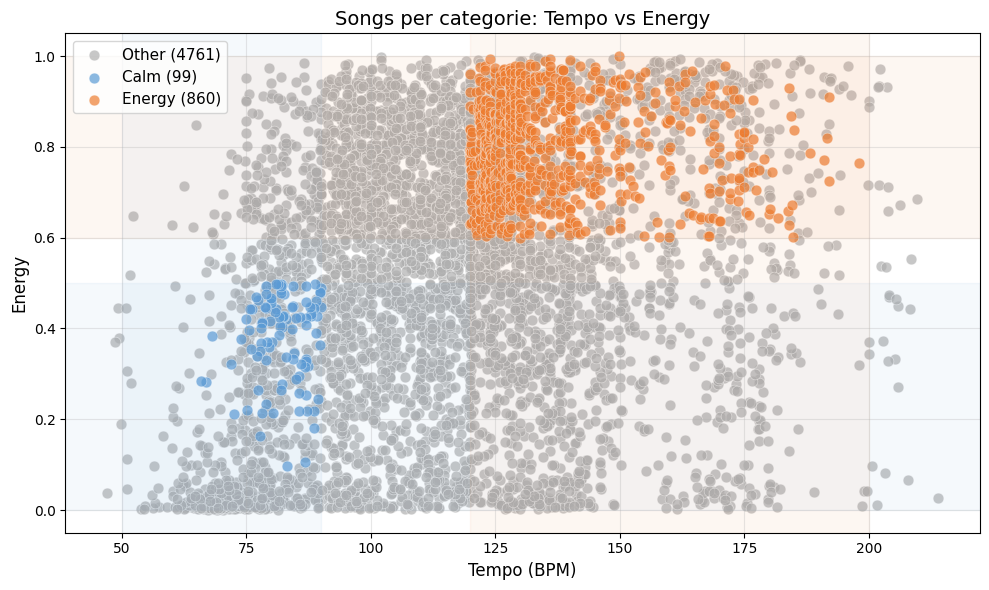

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter_kw = dict(alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

ax.scatter(other_df['tempo'],  other_df['energy'],  color='#b0b0b0', label=f'Other ({len(other_df)})',  **scatter_kw)
ax.scatter(calm_df['tempo'],   calm_df['energy'],   color='#5b9bd5', label=f'Calm ({len(calm_df)})',    **scatter_kw)
ax.scatter(energy_df['tempo'], energy_df['energy'], color='#ed7d31', label=f'Energy ({len(energy_df)})', **scatter_kw)

# Calm zone
ax.axvspan(CALM['tempo_min'], CALM['tempo_max'], alpha=0.06, color='#5b9bd5')
ax.axhspan(0, CALM['energy_max'], alpha=0.06, color='#5b9bd5')

# Energy zone
ax.axvspan(ENERGY['tempo_min'], ENERGY['tempo_max'], alpha=0.06, color='#ed7d31')
ax.axhspan(ENERGY['energy_min'], 1, alpha=0.06, color='#ed7d31')

ax.set_xlabel('Tempo (BPM)', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('Songs per categorie: Tempo vs Energy', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Songslijsten bekijken

In [10]:
# Welke kolommen wil je zien?
SHOW_COLS = ['name', 'artists', 'tempo', 'energy', 'acousticness', 'valence', 'loudness', 'danceability']
show_cols = [c for c in SHOW_COLS if c in df.columns]

print("🎵 CALM")
display(calm_df[show_cols].reset_index(drop=True).head(30))

🎵 CALM


,name,artists,tempo,energy,acousticness,valence,loudness,danceability
0,Life Is Long - ESCQ Remix,Wallis Bird;ESCQ,89.993,0.490,0.03410,0.569,-7.827,0.750
1,April Showers,Aïrto,89.989,0.447,0.39600,0.625,-8.914,0.768
2,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone;Swae Lee,89.908,0.478,0.55200,0.913,-5.574,0.760
3,E.I.,Nelly,89.847,0.481,0.07320,0.406,-7.824,0.834
4,Got 'Til It's Gone,Janet Jackson;Q-Tip;Joni Mitchell,89.842,0.364,0.01770,0.534,-10.375,0.752
5,Pegasi,Jesca Hoop,89.410,0.244,0.93900,0.508,-8.901,0.576
6,Ready or Not,Fugees;Ms. Lauryn Hill;Wyclef Jean;Pras,89.129,0.428,0.24500,0.524,-13.392,0.544
7,Wherever I Lay My Hat (That's My Home),Paul Young,88.989,0.390,0.22500,0.536,-12.959,0.610
8,Good People,Rhys Lewis,88.978,0.460,0.38100,0.419,-8.208,0.839
9,Maneater,Daryl Hall & John Oates,88.825,0.498,0.04050,0.823,-13.083,0.724


In [11]:
print("⚡ ENERGY")
display(energy_df[show_cols].reset_index(drop=True))

⚡ ENERGY


,name,artists,tempo,energy,acousticness,valence,loudness,danceability
0,Supermassive Black Hole,Muse,120.000,0.921,0.049200,0.782,-3.727,0.668
1,Brokenhearted,Karmin,120.001,0.765,0.007650,0.886,-2.732,0.765
2,Love Of Yesterday,Paul Lock,120.002,0.891,0.020100,0.772,-4.764,0.602
3,10:35,Tiësto;Tate McRae,120.003,0.793,0.068300,0.698,-5.733,0.696
4,Gypsy Woman (She's Homeless) (La Da Dee La Da ...,Crystal Waters,120.007,0.779,0.000165,0.453,-10.529,0.645
...,...,...,...,...,...,...,...,...
855,Changes,Charlie Puth,190.937,0.770,0.077400,0.598,-6.991,0.549
856,Back That Azz Up,JUVENILE;Lil Wayne;Mannie Fresh,191.686,0.820,0.033900,0.528,-3.350,0.752
857,The Greatest (feat. Kendrick Lamar),Sia;Kendrick Lamar,191.944,0.725,0.010200,0.729,-6.127,0.668
858,Azizam,Ed Sheeran,191.983,0.909,0.002470,0.871,-5.072,0.537


In [12]:
print("🎶 OTHER")
display(other_df[show_cols].reset_index(drop=True))

🎶 OTHER


,name,artists,tempo,energy,acousticness,valence,loudness,danceability
0,exile (feat. Bon Iver),Taylor Swift;Bon Iver,75.602,0.380,0.77800,0.152,-8.426,0.298
1,The Light Upon Us,Talos,95.133,0.640,0.58400,0.283,-3.484,0.253
2,Shine,Benjamin Francis Leftwich,118.067,0.512,0.65300,0.702,-10.388,0.715
3,Voilà,Barbara Pravi,135.379,0.337,0.77300,0.603,-8.665,0.447
4,Sleeptalking,Nona,106.612,0.245,0.90300,0.111,-7.947,0.378
...,...,...,...,...,...,...,...,...
4756,Black Jesus,9 Lazy 9,94.759,0.595,0.06310,0.523,-9.179,0.839
4757,Listen To The Beat,London Funk Allstars,95.913,0.461,0.01110,0.244,-12.782,0.713
4758,Snapper,Red Snapper;Beth Orton,94.748,0.449,0.08680,0.255,-10.823,0.700
4759,Eine Kleine Hedmusik,Coldcut,90.958,0.423,0.01520,0.223,-14.190,0.676


---
## 7. Opslaan als CSV

In [13]:
# ── Output map (pas aan indien nodig) ────────────────────────────────────────
OUTPUT_DIR = Path(f"../data/playlists/{PARTICIPANT}/playlists_output")
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(exist_ok=True)

calm_df.to_csv(OUTPUT_DIR / f"{PARTICIPANT}_calm.csv",   index=False)
energy_df.to_csv(OUTPUT_DIR / f"{PARTICIPANT}_energy.csv", index=False)
other_df.to_csv(OUTPUT_DIR / f"{PARTICIPANT}_other.csv",  index=False)

print(f"✅ Opgeslagen in '{OUTPUT_DIR}/'")
print(f"   {PARTICIPANT}_calm.csv   → {len(calm_df)} songs")
print(f"   {PARTICIPANT}_energy.csv → {len(energy_df)} songs")
print(f"   {PARTICIPANT}_other.csv  → {len(other_df)} songs")


✅ Opgeslagen in '..\data\playlists\courgette\playlists_output/'
   courgette_calm.csv   → 99 songs
   courgette_energy.csv → 860 songs
   courgette_other.csv  → 4761 songs
